# Filtering and trimming messages

## Review

Now, we have a deeper understanding of a few things: 

* How to customize the graph state schema
* How to define custom state reducers
* How to use multiple graph state schemas

## Goals

Now, we can start using these concepts with models in LangGraph!
 
In the next few sessions, we'll build towards a chatbot that has long-term memory.

Because our chatbot will use messages, let's first talk a bit more about advanced ways to work with messages in graph state.

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain_core langgraph langchain_openai

In [ ]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("MISTRAL_API_KEY")


We'll use [LangSmith](https://docs.langchain.com/langsmith/home) for [tracing](https://docs.langchain.com/langsmith/observability-concepts).

We'll log to a project, `langchain-academy`. 

In [ ]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "default"

## Messages as state

First, let's define some messages.

In [ ]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(f"So you said you were researching ocean mammals?", name="Bot")]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Abood"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Abood

Yes, I know about whales. But what others should I learn about?


Recall we can pass them to a chat model.

In [ ]:
from langchain_mistralai import ChatMistralAI
llm = ChatMistralAI(model="mistral-medium-latest", temperature = 0)
llm.invoke(messages).pretty_print()

================================== Ai Message ==================================

Great! The ocean is home to a fascinating diversity of marine mammals beyond whales. Here’s a breakdown of the major groups you should explore, along with key species and unique traits to research:

---

### **1. Dolphins (Family: Delphinidae)**
   - **Why they’re interesting**: Highly intelligent, social, and known for complex communication (e.g., signature whistles). Some use tools (e.g., sponges to protect their snouts while foraging).
   - **Key species to study**:
     - **Bottlenose dolphin** (*Tursiops truncatus*): Iconic, widespread, and studied for cognition (e.g., mirror self-recognition).
     - **Orca (killer whale)** (*Orcinus orca*): Technically the largest dolphin! Apex predators with diverse diets (seals, fish, even other whales) and matrilineal social structures.
     - **Spinner dolphin** (*Stenella longirostris*): Famous for acrobatic leaps.
     - **Amazon river dolphin** (*Inia geoffr

We can run our chat model in a simple graph with `MessagesState`.

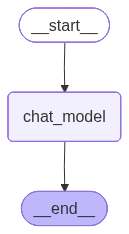

In [ ]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

# Node
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
output = graph.invoke({'messages': messages})

In [ ]:
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Abood

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Great! The ocean is home to a fascinating diversity of marine mammals beyond whales. Here’s a breakdown of the major groups you should explore, along with key species and unique traits to research:

---

### **1. Dolphins (Odontoceti – Toothed Whales)**
*(Technically whales, but often studied separately due to their intelligence and behavior.)*
- **Key Species**:
  - **Bottlenose Dolphin** (*Tursiops truncatus*) – Iconic, highly social, and used in research (e.g., communication, echolocation).
  - **Orca (Killer Whale)** (*Orcinus orca*) – Apex predators with complex social structures (matrilineal pods) and regio

## Reducer

A practical challenge when working with messages is managing long-running conversations. 

Long-running conversations result in high token usage and latency if we are not careful, because we pass a growing list of messages to the model.

We have a few ways to address this.

First, recall the trick we saw using `RemoveMessage` and the `add_messages` reducer.

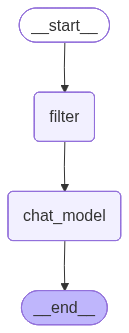

In [ ]:
from langchain_core.messages import RemoveMessage

# Node
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_message = [RemoveMessage(id = m.id) for m in state['messages'][:-2]]
    return {"messages": delete_message}

def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)

# Add Nodes
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)

# Add Edges
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)

# Compile Graph
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Abood", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Abood", id="4"))

# Invoke
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Abood

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Great! The ocean is home to a fascinating diversity of marine mammals beyond whales. Here’s a breakdown of the major groups you should explore, along with some standout species and key topics to research:

---

### **1. Cetaceans (Whales, Dolphins, and Porpoises)**
*(You already know whales, but here’s more!)*
- **Dolphins**:
  - **Bottlenose Dolphin** (*Tursiops truncatus*) – Highly intelligent, social, and famous for echolocation.
  - **Orca (Killer Whale)** (*Orcinus orca*) – Apex predators with complex social structures (matrilineal pods).
  - **Amazon River Dolphin** (*Inia geoffrensis*) – Pink freshwater do

## Filtering messages

If you don't need or want to modify the graph state, you can just filter the messages you pass to the chat model.

For example, just pass in a filtered list: `llm.invoke(messages[-1:])` to the model.

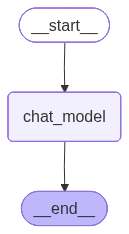

In [ ]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"][-1:])]}

# Build graph
builder = StateGraph(MessagesState)

# Add Nodes
builder.add_node("chat_model", chat_model_node)

# Add Edges
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)

# Compile Graph
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

Let's take our existing list of messages, append the above LLM response, and append a follow-up question.

In [ ]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Narwhals!", name="Abood"))

In [ ]:
for m in messages: 
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Abood

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Abood

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Great! The ocean is home to a fascinating diversity of marine mammals beyond whales. Here’s a breakdown of the major groups you should explore, along with some standout species and key topics to research:

---

### **1. Cetaceans (Whales, Dolphins, and Porpoises)**
*(You already know whales, but here’s more!)*
- **Dolphins**:
  - **Bottlenose Dolphin** (*Tursiops truncatus*) – Highly intelligent, social, and famous for ech

**Invoke, using message filtering**

In [ ]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Abood

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Abood

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Great! The ocean is home to a fascinating diversity of marine mammals beyond whales. Here’s a breakdown of the major groups you should explore, along with some standout species and key topics to research:

---

### **1. Cetaceans (Whales, Dolphins, and Porpoises)**
*(You already know whales, but here’s more!)*
- **Dolphins**:
  - **Bottlenose Dolphin** (*Tursiops truncatus*) – Highly intelligent, social, and famous for ech

The state has all of the mesages.

But, let's look at the LangSmith trace to see that the model invocation only uses the last message:

https://smith.langchain.com/public/75aca3ce-ef19-4b92-94be-0178c7a660d9/r

## Trim messages

Another approach is to [trim messages](https://docs.langchain.com/oss/python/langgraph/add-memory#trim-messages), based upon a set number of tokens. 

This restricts the message history to a specified number of tokens.

While filtering only returns a post-hoc subset of the messages between agents, trimming restricts the number of tokens that a chat model can use to respond.

See the `trim_messages` below.

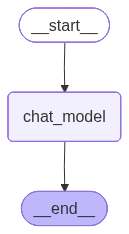

In [ ]:
from langchain_core.messages import trim_messages
import tiktoken

# Custom token counting function
def count_tokens(messages):
    enc = tiktoken.get_encoding("cl100k_base")
    return sum(len(enc.encode(m.content)) for m in messages)

# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens = 100,
            strategy = "last",
            token_counter = count_tokens,
            allow_partial = False,
        )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)

# Add Nodes 
builder.add_node("chat_model", chat_model_node)

# Add Edges
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)

# Compile Graph
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Abood"))

In [ ]:
messages

[AIMessage(content='Hi.', additional_kwargs={}, response_metadata={}, name='Bot', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Hi.', additional_kwargs={}, response_metadata={}, name='Abood', id='2'),
 AIMessage(content='So you said you were researching ocean mammals?', additional_kwargs={}, response_metadata={}, name='Bot', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Yes, I know about whales. But what others should I learn about?', additional_kwargs={}, response_metadata={}, name='Abood', id='4'),
 AIMessage(content='Great! The ocean is home to a fascinating diversity of marine mammals beyond whales. Here’s a breakdown of the major groups you should explore, along with some standout species and key topics to research:\n\n---\n\n### **1. Cetaceans (Whales, Dolphins, and Porpoises)**\n*(You already know whales, but here’s more!)*\n- **Dolphins**:\n  - **Bottlenose Dolphin** (*Tursiops truncatus*) – Highly intelligent, social, and famous 

In [ ]:
# Example of trimming messages
trim_messages(
            messages,
            max_tokens=100,
            strategy="last",
            token_counter=count_tokens,
            allow_partial=False
        )

[HumanMessage(content='Tell me where Orcas live!', additional_kwargs={}, response_metadata={}, name='Abood')]

In [ ]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

In [ ]:
for m in messages_out_trim['messages']: 
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Abood

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Abood

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Great! The ocean is home to a fascinating diversity of marine mammals beyond whales. Here’s a breakdown of the major groups you should explore, along with some standout species and key topics to research:

---

### **1. Cetaceans (Whales, Dolphins, and Porpoises)**
*(You already know whales, but here’s more!)*
- **Dolphins**:
  - **Bottlenose Dolphin** (*Tursiops truncatus*) – Highly intelligent, social, and famous for ech